In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.datasets import fetch_lfw_people

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'font.size': 12,
    'figure.dpi': 100,
})

Загружаем датасет LFW
Изображений: 3595
Размер патча: 62x47
Отфильтровано 2059 изображений
Мужчин 1861, Женщин 198


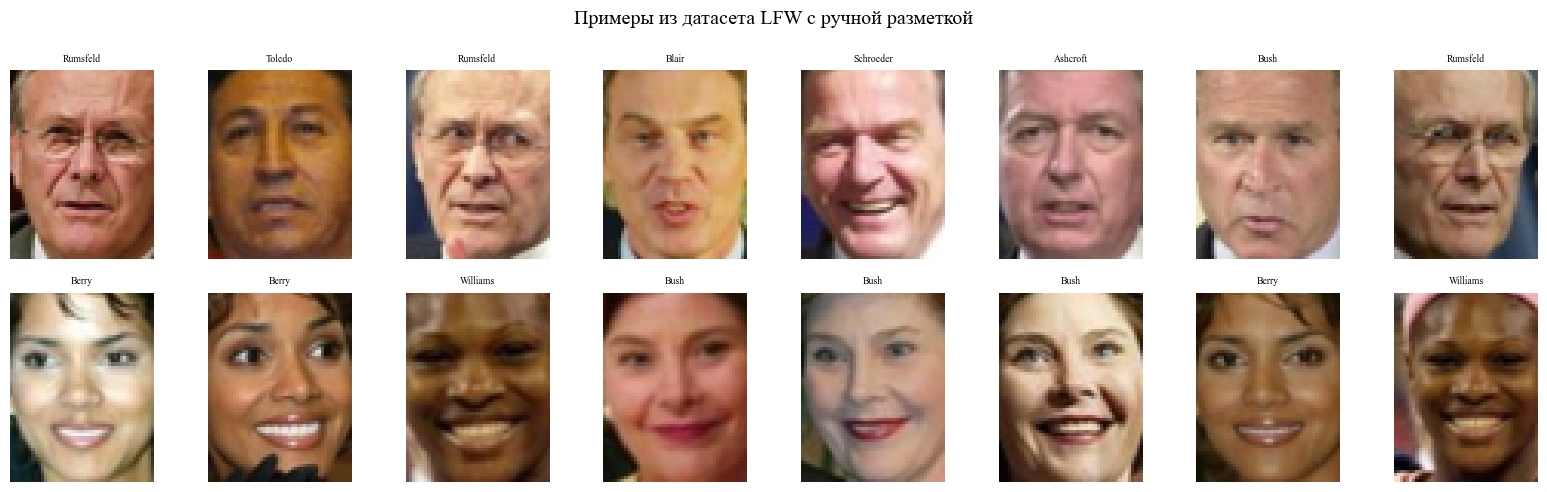

In [2]:
print('Загружаем датасет LFW')
lfw = fetch_lfw_people(min_faces_per_person=15, resize=0.5, color=True)
print(f'Изображений: {lfw.images.shape[0]}')
print(f'Размер патча: {lfw.images.shape[1]}x{lfw.images.shape[2]}')

GENDER_LABELS = {
    'Ariel Sharon': 0, 'Colin Powell': 0, 'Donald Rumsfeld': 0,
    'George W Bush': 0, 'Gerhard Schroeder': 0, 'Hugo Chavez': 0,
    'Tony Blair': 0, 'Junichiro Koizumi': 0, 'Jean Chretien': 0,
    'John Ashcroft': 0, 'Vladmir Putin': 0, 'Hamid Karzai': 0,
    'Luiz Inacio Lula da Silva': 0, 'Jacques Chirac': 0, 'Jiang Zemin': 0,
    'Vicente Fox': 0, 'Silvio Berlusconi': 0, 'Alejandro Toledo': 0,
    'John Snow': 0, 'Arnold Schwarzenegger': 0,
    'Lleyton Hewitt': 0, 'Andre Agassi': 0, 'Tiger Woods': 0,
    'Jennifer Aniston': 1, 'Halle Berry': 1, 'Laura Bush': 1,
    'Serena Williams': 1, 'Winona Ryder': 1,
    'Gloria Macapagal Arroyo': 1, 'Condoleezza Rice': 1,
}

valid_indices = []
gender_labels = []
for i, tid in enumerate(lfw.target):
    name = lfw.target_names[tid]
    if name in GENDER_LABELS:
        valid_indices.append(i)
        gender_labels.append(GENDER_LABELS[name])

images_valid = lfw.images[valid_indices]
y_gender = np.array(gender_labels)

print(f'Отфильтровано {len(images_valid)} изображений')
print(f'Мужчин {(y_gender==0).sum()}, Женщин {(y_gender==1).sum()}')

f, axes = plt.subplots(2, 8, figsize=(16, 5))
for row, gender in enumerate([0, 1]):
    idxs = np.where(y_gender == gender)[0][:8]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(images_valid[idx])
        axes[row, col].axis('off')
        name = lfw.target_names[lfw.target[valid_indices[idx]]]
        axes[row, col].set_title(name.split()[-1], fontsize=7)
axes[0,0].set_ylabel('Мужчины'); axes[1,0].set_ylabel('Женщины')
plt.suptitle('Примеры из датасета LFW с ручной разметкой')
plt.tight_layout(); plt.show()

In [3]:
IMG_SIZE = 64      

def preprocess_image(img):
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img_resized / 255.0

def preprocess_face_square(img):
    h, w = img.shape[:2]
    size = min(h, w)
    start_h = (h - size) // 2
    start_w = (w - size) // 2
    cropped = img[start_h:start_h+size, start_w:start_w+size]
    resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
    return resized / 255.0

X_faces_cnn = np.array([preprocess_image(img) for img in images_valid])
X_faces_cnn_sq = np.array([preprocess_face_square(img) for img in images_valid])

In [4]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split

try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

print("Загрузка UTKFace через kagglehub...")
path = kagglehub.dataset_download("jangedoo/utkface-new")
print("Путь к данным:", path)

n_male = np.sum(y_gender == 0)
n_female = np.sum(y_gender == 1)
print(f"LFW: мужчин {n_male}, женщин {n_female}")

needed_females = max(0, n_male - n_female)
print(f"Нужно добавить женщин: {needed_females}")

female_folder = os.path.join(path, "UTKFace") 
utk_images = []
utk_labels = []

for filename in os.listdir(female_folder):
    if not filename.lower().endswith('.jpg'):
        continue
    parts = filename.split('_')
    if len(parts) < 2:
        continue
    gender = int(parts[1]) 
    if gender == 1:
        img_path = os.path.join(female_folder, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        processed = preprocess_face_square(img)  
        utk_images.append(processed)
        utk_labels.append(1)
        if len(utk_images) >= needed_females:
            break

print(f"Загружено женских лиц из UTKFace: {len(utk_images)}")

X_lfw_original = X_faces_cnn_sq.copy()
y_lfw_original = y_gender.copy()

X_faces_cnn_sq = np.concatenate([X_faces_cnn_sq, np.array(utk_images)])
y_gender = np.concatenate([y_gender, np.array(utk_labels)])

indices = np.random.permutation(len(y_gender))
X_faces_cnn_sq = X_faces_cnn_sq[indices]
y_gender = y_gender[indices]

print(f"Итоговый размер: {len(y_gender)} изображений")
print(f"Мужчины: {np.sum(y_gender == 0)}, Женщины: {np.sum(y_gender == 1)}")

X_tr_gen, X_te_gen, y_tr_gen, y_te_gen = train_test_split(
    X_faces_cnn_sq, y_gender, test_size=0.2,
    random_state=42, stratify=y_gender
)
print(f"Train: {len(y_tr_gen)} (муж {np.sum(y_tr_gen==0)}, жен {np.sum(y_tr_gen==1)})")
print(f"Test:  {len(y_te_gen)} (муж {np.sum(y_te_gen==0)}, жен {np.sum(y_te_gen==1)})")

C:\Users\Mob\Desktop\filters\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка UTKFace через kagglehub...
Путь к данным: C:\Users\Mob\.cache\kagglehub\datasets\jangedoo\utkface-new\versions\1
LFW: мужчин 1861, женщин 198
Нужно добавить женщин: 1663
Загружено женских лиц из UTKFace: 1663
Итоговый размер: 3722 изображений
Мужчины: 1861, Женщины: 1861
Train: 2977 (муж 1488, жен 1489)
Test:  745 (муж 373, жен 372)


In [5]:
print('Генерируем правильные негативы (синтетика + CIFAR-10)')

# Синтетические негативы
def generate_synthetic_negatives(n_samples, h=62, w=47):
    negs = []
    for _ in range(n_samples):
        choice = np.random.rand()
        if choice < 0.3:  
            img = np.random.rand(h, w, 3).astype(np.float32)
        elif choice < 0.6:  
            img = np.ones((h, w, 3), dtype=np.float32) * np.random.uniform(0, 0.3)
            for _ in range(np.random.randint(1, 5)):
                color = np.random.rand(3)
                if np.random.rand() < 0.5:
                    x1, y1 = np.random.randint(0, w//2), np.random.randint(0, h//2)
                    x2, y2 = np.random.randint(x1+5, w), np.random.randint(y1+5, h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, -1)
                else:
                    center = (np.random.randint(10, w-10), np.random.randint(10, h-10))
                    radius = np.random.randint(5, 15)
                    cv2.circle(img, center, radius, color, -1)
        else:  
            x = np.linspace(0, 1, w)
            y = np.linspace(0, 1, h)
            xx, yy = np.meshgrid(x, y)
            img = np.zeros((h, w, 3), dtype=np.float32)
            for c in range(3):
                img[:,:,c] = np.sin(xx*10 + yy*10 + np.random.rand()*2) * 0.5 + 0.5
        negs.append(img)
    return negs

# Негативы из датасета CIFAR-10 
from tensorflow.keras.datasets import cifar10

(x_cifar, _), (_, _) = cifar10.load_data() 

def extract_patches_from_cifar(cifar_images, n_patches, patch_h=62, patch_w=47):
    patches = []
    bigger = max(patch_h, patch_w) * 2  
    bigger = 128
    for _ in range(n_patches):
        idx = np.random.randint(0, len(cifar_images))
        img = cifar_images[idx].astype(np.float32) / 255.0   
        img_big = cv2.resize(img, (bigger, bigger))          
        y = np.random.randint(0, bigger - patch_h + 1)
        x = np.random.randint(0, bigger - patch_w + 1)
        patch = img_big[y:y+patch_h, x:x+patch_w, :]
        patches.append(patch)
    return patches

N_NEG = len(images_valid)       
half = N_NEG // 2

np.random.seed(42)

synth_negs = generate_synthetic_negatives(half)
cifar_negs = extract_patches_from_cifar(x_cifar, half)

neg_patches = synth_negs + cifar_negs
np.random.shuffle(neg_patches)

print(f'Создано синтетических: {len(synth_negs)}, из CIFAR-10: {len(cifar_negs)}')
print(f'Всего негативов: {len(neg_patches)}')

Генерируем правильные негативы (синтетика + CIFAR-10)


C:\Users\Mob\Desktop\filters\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Создано синтетических: 1029, из CIFAR-10: 1029
Всего негативов: 2058


In [6]:
X_neg_cnn = np.array([preprocess_image(patch) for patch in neg_patches])

X_det_cnn = np.concatenate([X_faces_cnn, X_neg_cnn])
y_det_cnn = np.concatenate([np.ones(len(X_faces_cnn)), np.zeros(len(X_neg_cnn))])

X_tr_det, X_te_det, y_tr_det, y_te_det = train_test_split(
    X_det_cnn, y_det_cnn, test_size=0.2,
    random_state=42, stratify=y_det_cnn
)

In [7]:
model_det = models.Sequential([
    layers.Input(shape=(64,64,3)),          
    layers.RandomFlip("horizontal"),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.GlobalAveragePooling2D(),       
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model_det.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                     restore_best_weights=True)

print("Обучаем детектор лицо / не-лицо (CNN)...")
history_det = model_det.fit(
    X_tr_det, y_tr_det,
    validation_data=(X_te_det, y_te_det),
    epochs=40, batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

test_loss_det, test_acc_det = model_det.evaluate(X_te_det, y_te_det, verbose=0)
print(f'Точность детектора (CNN): {test_acc_det:.3f}')

Обучаем детектор лицо / не-лицо (CNN)...
Epoch 1/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8989 - loss: 0.3849 - val_accuracy: 0.5000 - val_loss: 0.7411
Epoch 2/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9393 - loss: 0.2266 - val_accuracy: 0.5000 - val_loss: 0.7463
Epoch 3/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9514 - loss: 0.1794 - val_accuracy: 0.5012 - val_loss: 0.7208
Epoch 4/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9669 - loss: 0.1396 - val_accuracy: 0.9320 - val_loss: 0.5578
Epoch 5/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9787 - loss: 0.1072 - val_accuracy: 0.5000 - val_loss: 3.5165
Epoch 6/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9821 - loss: 0.0905 - val_accuracy: 0.5000 - val_loss: 9.7436
Epoch 7/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9833 - loss: 0.0821 - val_accuracy: 0.8046 - val_loss: 0.4249
Epoch 8/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - a

Веса классов: мужчины – 1.00, женщины – 1.00
Обучаем классификатор пола
Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.9335 - loss: 0.3208 - val_accuracy: 0.9436 - val_loss: 0.6686 - learning_rate: 5.0000e-04
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9452 - loss: 0.2616 - val_accuracy: 0.9503 - val_loss: 0.4474 - learning_rate: 5.0000e-04
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9456 - loss: 0.2518 - val_accuracy: 0.9503 - val_loss: 0.2954 - learning_rate: 5.0000e-04
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.9446 - loss: 0.2558 - val_accuracy: 0.9503 - val_loss: 0.2436 - learning_rate: 5.0000e-04
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9463 - loss: 0.2441 - val_accuracy: 0.9503 - val_loss: 0.2350 - learning_rate: 5.0000e-04
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9456 - loss: 0.2474 - val_accuracy: 0.9503 - val_loss: 0.2337 - learning_rate: 5.0

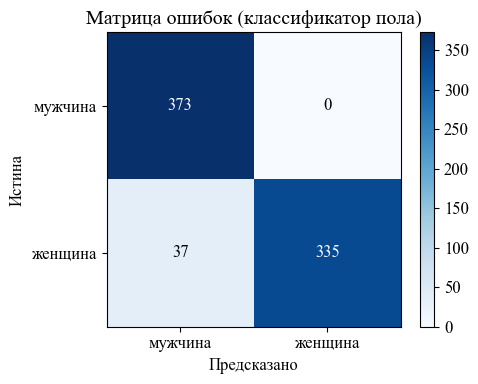

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


tf.random.set_seed(42)
np.random.seed(42)

BATCH_SIZE = 32
EPOCHS = 100

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])


def augment(image, label):
    return augmentation(image), label

train_dataset = tf.data.Dataset.from_tensor_slices((X_tr_gen, y_tr_gen))
test_dataset  = tf.data.Dataset.from_tensor_slices((X_te_gen, y_te_gen))

train_ds = train_dataset.shuffle(500).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_dataset.batch(BATCH_SIZE)


model_gen = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.5),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])


model_gen.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


n_male = np.sum(y_tr_gen == 0)
n_female = np.sum(y_tr_gen == 1)
total = n_male + n_female
weight_for_0 = (1 / n_male) * (total / 2.0)
weight_for_1 = (1 / n_female) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f"Веса классов: мужчины – {weight_for_0:.2f}, женщины – {weight_for_1:.2f}")


early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


print("Обучаем классификатор пола")
history_gen = model_gen.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


test_loss_gen, test_acc_gen = model_gen.evaluate(test_ds, verbose=0)
print(f'\nТочность классификатора пола на тесте: {test_acc_gen:.3f}')


y_pred_probs = model_gen.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_te_gen, y_pred, target_names=['мужчина', 'женщина']))

cm = confusion_matrix(y_te_gen, y_pred)


plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Матрица ошибок (классификатор пола)')
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['мужчина', 'женщина'])
plt.yticks(tick_marks, ['мужчина', 'женщина'])
plt.xlabel('Предсказано')
plt.ylabel('Истина')


thresh = cm.max() / 2.
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

In [9]:
def image_pyramid_manual(image_uint8, scale=0.85, min_size=64):
    img = image_uint8.copy()
    factor = 1.0
    while True:
        yield img, factor
        h, w = img.shape[:2]
        new_h, new_w = int(h * scale), int(w * scale)
        if new_h < min_size or new_w < min_size:
            break
        img = bilinear_resize(img, new_h, new_w)
        factor *= scale

def sliding_window_manual(image_uint8, win_h, win_w, step=16):
    h, w = image_uint8.shape[:2]
    for r in range(0, h - win_h + 1, step):
        for c in range(0, w - win_w + 1, step):
            yield r, c, image_uint8[r:r+win_h, c:c+win_w]

def iou_manual(boxA, boxB):
    r0 = max(boxA[0], boxB[0]); c0 = max(boxA[1], boxB[1])
    r1 = min(boxA[2], boxB[2]); c1 = min(boxA[3], boxB[3])
    inter = max(0, r1-r0) * max(0, c1-c0)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def nms_manual(detections, iou_thresh=0.3):
    if not detections: return []
    detections = sorted(detections, key=lambda x: x[0], reverse=True)
    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)
        detections = [d for d in detections if iou_manual(best[1:], d[1:]) < iou_thresh]
    return kept

In [10]:
def detect_and_classify_cnn(image_uint8, model_det, model_gen,
                            win_h=IMG_SIZE, win_w=IMG_SIZE,
                            step=16, scale=0.85,
                            det_threshold=0.5, iou_thresh=0.3):
    detections = []
    for img_scaled, factor in image_pyramid_manual(image_uint8, scale=scale):
        for r, c, patch in sliding_window_manual(img_scaled, win_h, win_w, step):
            patch_resized = cv2.resize(patch, (IMG_SIZE, IMG_SIZE)) / 255.0
            patch_batch = np.expand_dims(patch_resized, axis=0)
            prob = model_det.predict(patch_batch, verbose=0)[0, 0]

            if prob > det_threshold:
                r0 = int(r / factor); c0 = int(c / factor)
                r1 = int((r + win_h) / factor); c1 = int((c + win_w) / factor)
                detections.append((prob, r0, c0, r1, c1))

    detections = nms_manual(detections, iou_thresh)

    results = []
    for prob, r0, c0, r1, c1 in detections:
        crop = image_uint8[r0:r1, c0:c1]
        if crop.size == 0: continue
        crop_resized = cv2.resize(crop, (IMG_SIZE, IMG_SIZE)) / 255.0
        crop_batch = np.expand_dims(crop_resized, axis=0)
        gender_pred = np.argmax(model_gen.predict(crop_batch, verbose=0))
        results.append((r0, c0, r1, c1, gender_pred))
    return results

print(f'Размер окна детектора {IMG_SIZE}×{IMG_SIZE} пикселей')

Размер окна детектора 64×64 пикселей


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
✅ Оптимальный порог для детектора: 0.135
Детектор (CNN):
              precision    recall  f1-score   support

     не-лицо       0.98      0.98      0.98       412
        лицо       0.98      0.98      0.98       412

    accuracy                           0.98       824
   macro avg       0.98      0.98      0.98       824
weighted avg       0.98      0.98      0.98       824

Детектор (CNN):
              precision    recall  f1-score   support

     не-лицо       0.98      0.98      0.98       412
        лицо       0.98      0.98      0.98       412

    accuracy                           0.98       824
   macro avg       0.98      0.98      0.98       824
weighted avg       0.98      0.98      0.98       824

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Пол (CNN):
              precision    recall  f1-score   support

     мужчина       0.91      1.00      0.95       373
     женщина       1.00      0.90      0.95       372

    accuracy      

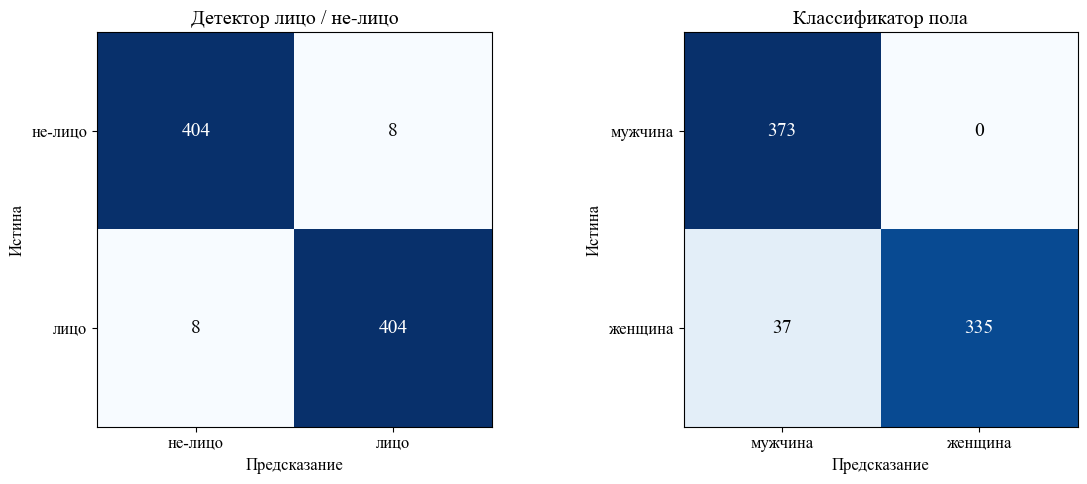

Точность детектора (CNN):           0.981
Точность классификатора пола (CNN): 0.950


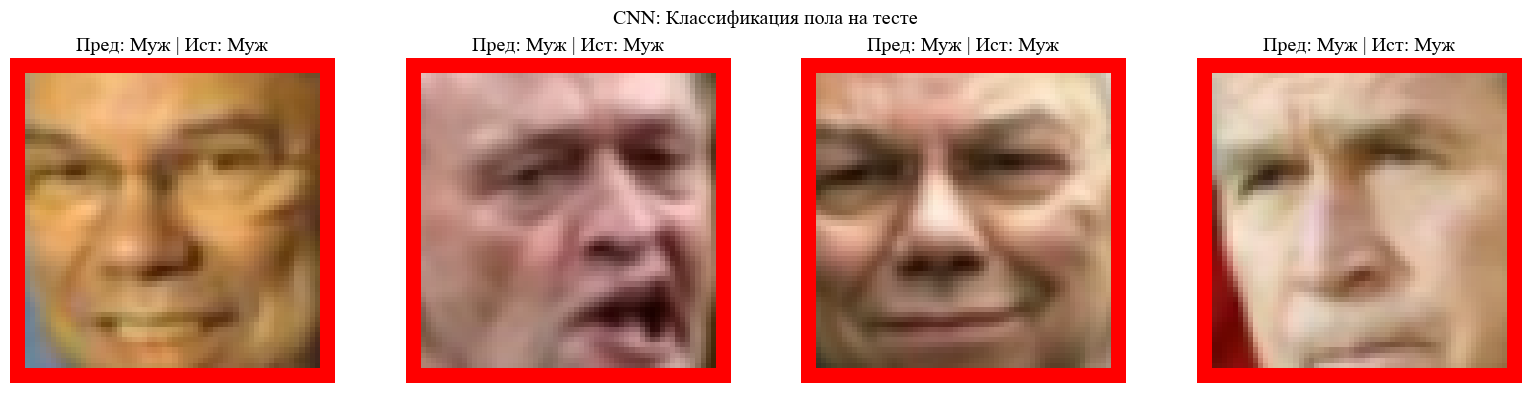

In [11]:
from sklearn.metrics import precision_recall_curve

probs_det = model_det.predict(X_te_det).flatten()

prec, rec, thresholds = precision_recall_curve(y_te_det, probs_det)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-7)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"✅ Оптимальный порог для детектора: {best_thresh:.3f}")

y_pred_det = (probs_det > best_thresh).astype(int)
y_true_det = y_te_det

cm_det = confusion_matrix(y_true_det, y_pred_det, labels=[0, 1])
print("Детектор (CNN):")
print(classification_report(y_true_det, y_pred_det, target_names=['не-лицо', 'лицо']))
print("Детектор (CNN):")
print(classification_report(y_true_det, y_pred_det, target_names=['не-лицо', 'лицо']))

y_pred_gen = np.argmax(model_gen.predict(X_te_gen), axis=1)
cm_gen = confusion_matrix(y_te_gen, y_pred_gen, labels=[0, 1])
print("Пол (CNN):")
print(classification_report(y_te_gen, y_pred_gen, target_names=['мужчина', 'женщина']))

f, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title, labels in [
    (axes[0], cm_det, 'Детектор лицо / не-лицо', ['не-лицо', 'лицо']),
    (axes[1], cm_gen, 'Классификатор пола', ['мужчина', 'женщина'])
]:
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_ylabel('Истина'); ax.set_xlabel('Предсказание')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Точность детектора (CNN):           {accuracy_score(y_true_det, y_pred_det):.3f}')
print(f'Точность классификатора пола (CNN): {accuracy_score(y_te_gen, y_pred_gen):.3f}')

#np.random.seed(123)   
n_lfw = len(y_lfw_original)
test_imgs_idx = np.random.choice(n_lfw, 4, replace=False)

f, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, idx in enumerate(test_imgs_idx):
    img = X_lfw_original[idx].copy()
    true = y_lfw_original[idx]
    
    img_batch = np.expand_dims(img, axis=0)
    probs = model_gen.predict(img_batch, verbose=0)[0]
    pred = np.argmax(probs)
    
    vmin, vmax = img.min(), img.max()
    if vmax - vmin > 1e-6:
        img_disp = (img - vmin) / (vmax - vmin)
    else:
        img_disp = img
    
    color = [1.0, 0.0, 0.0] if pred == 0 else [0.0, 0.0, 1.0]
    img_disp[:3, :, :] = color
    img_disp[-3:, :, :] = color
    img_disp[:, :3, :] = color
    img_disp[:, -3:, :] = color
    
    axes[i].imshow(img_disp)
    axes[i].set_title(f'Пред: {"Муж" if pred==0 else "Жен"} | Ист: {"Муж" if true==0 else "Жен"}')
    axes[i].axis('off')

plt.suptitle('CNN: Классификация пола на тесте')
plt.tight_layout()
plt.show()